- 如何分析 pg loss （GRPO）
    - pg loss vs. supervised learning loss
    - Advantage 的标准化对 pg loss 的影响
    - GRPO objective analysis
    - cases study of PPO loss (为正/为负)
    - Deep REINFORCE on cartpole (on-policy)

In [6]:
from IPython.display import Image

- 真目标：$J(\theta) = \mathbb{E}_{\tau \sim \pi_{\theta}}[\sum_t r_t]$.
    - $\pi$ 有随机性的，$R=\sum_{t=1}r_t$ 是一个随机变量
    - 更应该关注期望：$\sum_\tau p_\theta(\tau)R(\tau)$ （遍历穷举所有的 trajectory）
- REINFORCE 给出无偏梯度估计：
    - $G_t = \sum_{k=t}^{T-1} \gamma^{k-t} r_k.$

$$
\nabla_{\theta} J(\theta) = \mathbb{E}\bigg[\sum_t (G_t-b_t) \nabla_{\theta} \log \pi_{\theta}(a_t|s_t)\bigg].
$$

- 为了用自动微分，我们构造一个“可微代理”：

$$
L_{PG}(\theta) = -\mathbb{E}\bigg[\sum_t (G_t - b_t) \log \pi_{\theta}(a_t|s_t)\bigg],
$$

并在实现中把$\{s_t, a_t, G_t, b_t\}$ 当常值 (对采样过程 stop-grad)，于是
$\nabla_{\theta} L_{PG}(\theta) = -\mathbb{E}\big[\sum_t (G_t - b_t) \nabla_{\theta} \log \pi_{\theta}(a_t|s_t)\big]$
刚好等于 $-\nabla_{\theta}J(\theta)$.（也就是梯度方向一致）

- PG loss 是“为拿到正确梯度而设计的 surrogate”，不是“可直接代表性能的目标值”。
    - 让深度学习优化器能做梯度下降而构造的负的梯度估计器（surrogate）。
    - 我们只需要 $\nabla_{\theta} L_{PG}$ 与 $-\nabla_{\theta} J$ 相等；并没有要求 $L_{PG}$ 的数值等于 $-J$.
- 再者，基线 $b_t$ (以及 Advantage 的归一化/缩放) 不改变梯度的期望，却会任意改变 $L_{PG}$ 的数值。所以画出来的 “PG loss 曲线” 没有统一标尺，与 $J(\theta)$ 的大小/单调性不具备稳定对应关系。

### pg vs. sl

https://karpathy.github.io/2016/05/31/rl/
- 这里也可以对比 pg loss 跟 supervised learning（cross entropy loss）
    - $\sum_i \log p(y_i \mid x_i)$: ground truth label
        - minimize cross entropy loss = maximize log likelihood
    - $\sum_i A_i \log p(y_i \mid x_i)$
      1. we have no (action) labels so we sample: $y_i\sim p(\cdot|x_i)$（基于当前策略采样数据）
      2. once we collect a batch of rollouts: maximize $\sum_i A_i\log(y_i|x_i)$（基于 DNN 的最优化问题）

- reward vs. return
    - reward 是当下这一步环境给你的“即时评分”；return 是从某个时间点往后把所有未来评分（常用折扣）加总后的总成绩，算法真正最大化的是 return 的期望。
    - 回报也被称为累积奖励（Cumulative Reward）

In [2]:
Image(url='./figs/discounted-rewards.png', width=400)

In [3]:
-1 * 0.9**0, -1 * 0.9**1, -1 * 0.9 **2

(-1.0, -0.9, -0.81)

In [4]:
-1 * 0.9 **3 + 1 * 0.9 ** 0, -1 * 0.9 **4 + 1 * 0.9 ** 1, -1 * 0.9 **5 + 1 * 0.9 ** 2

(0.2709999999999999, 0.2439, 0.21950999999999998)

- discounted rewards: 未来的价值折现
    - 一个动作对越久之后发生的回报，所负的责任越小。离奖励（或惩罚）越近的动作，责任越大。
- advantage：$G_t$ 不要总是正的或总是负的；
    - 优势 (Advantage) = 实际得到的回报 (Actual Return) - 期望的回报 (Baseline)
    - 减去 Baseline 的核心目的，就是将奖励信号进行中心化处理，提供一个相对的衡量标准。
        - 它不再关心绝对的得分是正还是负。
        - 它只关心这次的表现是比预想的好，还是比预想的差。
    - 一个一直输的例子
        - AI玩了很多局后，通过学习，它知道自己目前水平的平均得分（Baseline）大概是 -20分。
        - 现在，它又玩了一局，采取了一系列动作，最终得分是 -18分。
        - 计算优势值：Advantage = (-18) - (-20) = +2。
        - 尽管这一局还是输了，但优势值是正的！这告诉算法：“你这次的表现比你平时的平均水平要好！你刚才做的那些动作是值得鼓励的！” 于是，算法会去增加这一系列动作的概率。

### loss curve or reward curve

https://x.com/burkov/status/1894986776156217858

$$
\mathcal{L}_k(\theta) = - \underbrace{ \mathbb{E}_{(x,y) \sim \mathcal{D}_k} \left[ \min \left( r_\theta A, \text{clip}(r_\theta, 1 - \epsilon, 1 + \epsilon) A \right) \right] }_{\text{策略 (PG) 项}} + \beta \cdot \underbrace{ \mathbb{E}_{x \sim \mathcal{D}_k} \left[ \text{KL}(\pi_\theta(\cdot|x) || \pi_{\text{ref}}(\cdot|x)) \right] }_{\text{KL 正则}}
$$
- $r_\theta=\exp(\log\pi_\theta-\log\pi_{\theta_k})$，是比率
- pg 项（-min）正优势答案的 $\log\pi_\theta$ 变大（概率上升），负优势的概率下降
- 损失函数在每次迭代都“变了”。更精确地说：
    - 第 $k$ 次，更新用的是 $\mathcal L_k(\theta)$，它的期望是对上一步策略 $\pi_{\theta_k}$ 采样得到的数据分布 $D_k$ 求的
    - 第 $k+1$ 次，更新用的是 $\mathcal L_{k+1}(\theta)$，它的期望是对上一步策略 $\pi_{\theta_{k+1}}$ 采样得到的数据分布 $D_{k+1}$ 求的
    - 它们不是同一个函数在不同参数点的值，而是不同的函数各自在各自最末参数点的值。横向不可比。
        - 这与监督学习形成鲜明对比：监督学习的 loss（数据集 + 度量）是固定的，只是参数在变，所以“同一函数值”的下降有意义。
    - 跨步比较没有单调性可言。
- that in supervised learning, the loss is a sort of difference between what the model predicts and what it was supposed to predict. This latter part, called the **training dataset**, is always the **same**. It came from some distribution we don't know, but it's **static**.
- In GRPO, like in this illustration, the loss function is also a difference. But a difference between the advantage (kind of a reward proxy) and the KL divergence (kind of an anchor that doesn't let us diverge too much from our initial model).
    - But the mind-blowing realization is that the **data used to calculate the advantage is sampled from the model itself**. Therefore, the loss function used at the previous step was trained on the training data coming from a different distribution than the loss function used at the current iteration.
    - the loss increases on the graph, but at each step, it's the value of a different loss function. So, basically, it's apple, then orange, then potato, then tomato... **Values that aren't meaningfully comparable**. And the fact that the values grow actually reflects the fact that the model learns well: the KL divergence increases, and this is what we observe here.
- The reason here is that when you plot the loss in supervised learning, you show how one loss function evolves over time. In RL, when you plot the loss, you plot at each time step a different loss function evolved only once. Next time step, the loss function is different.


### PG loss “表示”什么

- 把单个时间步看作一个样本，PG loss 的单样本项是
$$
\ell_t(\theta)=-(G_t-b_t)\log\pi(a_t|s_t)
$$
- $\log(a_t|s_t)$: 当前策略对“已选动作”的对数概率（提高它 = 沿梯度让该动作更可能）。
- $(G_t-b_t)$: 这次选择的“优势/信用分”（高于基线就奖励、低于基线就惩罚）。
- 乘积：让“好动作”的 $\log\pi$ 变大，让“差动作”的 $\log\pi$ 变小——这正是策略梯度的含义。
    - 高动作，梯度上升；坏动作，梯度下降；
- PG loss 的“意义”是：把 Advantage 当作权重，去拉升/压低采到的动作概率；

### pg loss 分析

- 一个具体的 training wandb log
    - https://wandb.ai/lingchang-ustc/search_async_rl/workspace?nw=nwuserlingchang
    - 监控 metric 各个 loss components 的 curves
        - pg_loss, kl_loss, entropy_loss
- 优势标准化（whiten）对 loss 的影响
    - $\tilde A_t=\frac{A_t-\mathbb E[A]}{\text{Std}(A)}, \quad L_{\text{pg}}=-\mathbb E[\tilde A_t\log\pi_\theta(a_t|s_t)]$
        - 优势是一个相对值
    - 对期望进行分解：$\mathbb{E}[\tilde{A} \log \pi] = \underbrace{\operatorname{Cov}(\tilde{A}, \log \pi)}_{\text{相关性项}} + \underbrace{\mathbb{E}[\tilde{A}] \, \mathbb{E}[\log \pi]}_{=0}= \operatorname{Cov}(\tilde{A}, \log \pi)$
        - 相关性 > 0：在给定状态 $s$ 内，优势大的动作（更好）被赋予更高的对数概率（策略更偏好它们）。
            - loss < 0，优化会继续朝“更偏好好动作”的方向推进
        - 相关性 < 0：策略更偏好劣势动作（糟糕）。
            - loss > 0，梯度会强力把概率往相反方向拉。
        - 相关性 ≈ 0：策略对“好/坏动作”的偏好没形成显著线性关系，或这层关系被“重新定标”抵消了。
- https://github.com/huggingface/open-r1/issues/239#issuecomment-2646297851
    - https://www.bilibili.com/video/BV1LgXbY5EFD
        - loss 为 0，不代表 grad 为 0，还是有梯度信号的
    - $J(\theta)=\mathbb E[r_t(\theta)\hat A_t], \quad r_t(\theta)=\exp(\log\pi_\theta-\log\pi_{old})$
        - $\nabla_{\theta} J(\theta)|_{\theta=\theta_{\text{old}}} = \mathbb{E}[\hat{A}_t \nabla_{\theta} \log \pi_{\theta}(a_t | s_t)]$

$$
\begin{split}
\mathcal{J}_{GRPO}(\theta)&= \frac{1}{G} \sum_{i=1}^G \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \min \left( \frac{\pi_\theta(o_{i,t}|q, o_{i,<t})}{\pi_{\theta_{old}}(o_{i,t}|q, o_{i,<t})} \hat{A}_{i,t}, \text{clip} \left( \frac{\pi_\theta(o_{i,t}|q, o_{i,<t})}{\pi_{\theta_{old}}(o_{i,t}|q, o_{i,<t})}, 1-\varepsilon, 1+\varepsilon \right) \hat{A}_{i,t} \right) - \beta D_{KL} (\pi_\theta || \pi_{ref}) \\
&=\frac1G\sum_i^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\hat A_{i,t} -\frac1G\sum_{i=1}^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\beta D_{kl}[\pi_\theta|\pi_{ref}]\\
&=\frac1G\sum_i^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\hat A_i -\frac1G\sum_{i=1}^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\beta D_{kl}[\pi_\theta|\pi_{ref}]\\
&=\frac1G\sum_i^G\frac1{|o_i|} {|o_i|}\cdot \hat A_i -\frac1G\sum_{i=1}^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\beta D_{kl}[\pi_\theta|\pi_{ref}]\\
&=\frac1G\sum_i^G\hat A_i-\frac1G\sum_{i=1}^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\beta D_{kl}[\pi_\theta|\pi_{ref}]\\
&=\frac1G\sum_i^G\frac{r_i-\mu}{\sigma}-\frac1G\sum_{i=1}^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\beta D_{kl}[\pi_\theta|\pi_{ref}]\\
&=\frac{\sum_i r_i-G\mu}{G}-\frac1G\sum_{i=1}^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\beta D_{kl}[\pi_\theta|\pi_{ref}]\\
&= 0 -\frac1G\sum_{i=1}^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\beta D_{kl}[\pi_\theta|\pi_{ref}]\\
&=-\frac1G\sum_{i=1}^G\frac1{|o_i|}\sum_{t=1}^{|o_i|}\beta D_{kl}[\pi_\theta|\pi_{ref}]
\end{split}
$$

- batch1
    - ratios：1.18, 1.1, 0.9, 0.92
    - advs：2, 1, -1.5, -1.5 (mean = 0)
    - 正优势样本的 $r\gt 1$：1.18 \* 2, 1.1 \* 1
    - 负优势样本的 $r\lt 1$：0.8 \* -1.5, 0.92 * (-1.5)
    - 好样本稍微涨一点概率，坏样本稍微降一点概率，且都没触发 clip，正贡献略占优 ⇒ 目标 > 0
- batch2
    - ratios：0.85, 0.88, 0.82, 1.5
    - advs: 2, 1, -1.5, -1.5 (mean = 0)
    - 好样本概率下降（r<1，削弱正贡献），坏样本里有一个 r 大涨且被按更差的一边记账，负贡献占优 ⇒ 目标 < 0。
- 纯 on-policy 时，$\pi_{old} == \pi_\theta$
    - 所有的 ratios = 1，mean(advs)=0（因为被归一化）loss = 0
- 围绕0上下震荡原因 case 分析
    - 当正优势样本多配到 r ≥ 1、负优势样本多配到 r ≤ 1 且少触发不利的剪裁分支时，L_clip 往往 > 0；反之则 < 0。

In [1]:
import numpy as np
def ppo_terms(A, r, eps=0.2):
    """
    输入:
      A   : 优势 (numpy array)，可以已做零均值/标准化或组内中心化
      r   : 概率比 r = pi_new / pi_old
      eps : PPO-clip 的 epsilon
    返回:
      A, r, r_clip, term_pg=r*A, term_clip=min(r*A, clip(r)*A)
    """
    A = np.asarray(A, dtype=float)
    r = np.asarray(r, dtype=float)
    r_clip = np.clip(r, 1 - eps, 1 + eps)
    term_pg = r * A
    term_clip = np.minimum(term_pg, r_clip * A)  # PPO-clip 的 per-sample 目标项
    return A, r, r_clip, term_pg, term_clip

In [5]:
A_A = [ 2.0,  1.0, -1.5, -1.5]   # sum = 0
R_A = [ 1.18, 1.10, 0.90, 0.92]  # 全在 [0.8, 1.2] 内，不触发剪裁
A, r, r_clip, term_pg, term_clip = ppo_terms(A_A, R_A, eps=0.2)

In [11]:
L_pg = -term_pg.mean()
L_clip = -term_clip.mean()
L_pg, L_clip

(np.float64(-0.18249999999999994), np.float64(-0.18249999999999994))

In [13]:
A_B = [ 2.0,  1.0, -1.5, -1.5]   # sum = 0
R_B = [ 0.85, 0.88, 0.82, 1.50]  # 最后一个 > 1+eps 触发上限
A, r, r_clip, term_pg, term_clip = ppo_terms(A_B, R_B, eps=0.2)

In [14]:
L_pg = -term_pg.mean()
L_clip = -term_clip.mean()
L_pg, L_clip

(np.float64(0.22499999999999998), np.float64(0.22499999999999998))

### REINFORCE on cartpole

- https://hrl.boyuai.com/chapter/2/%E7%AD%96%E7%95%A5%E6%A2%AF%E5%BA%A6%E7%AE%97%E6%B3%95
- on policy 特性
    - 基于当前策略，生成的一条轨迹（trajectory），只用来训练一次神经网络；然后根据新的 policy 采样 => 训练
    - 一条数据只用来训练一次，不可以重复利用；

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 定义策略网络
class Policy(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Policy, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        return self.network(state)

# REINFORCE 智能体
class ReinforceAgent:
    def __init__(self, state_dim, action_dim):
        self.policy = Policy(state_dim, action_dim).to(DEVICE)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=LEARNING_RATE)
        self.saved_log_probs = []
        self.rewards = []

    def select_action(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(DEVICE)
        probs = self.policy(state)
        m = Categorical(probs)
        action = m.sample()
        self.saved_log_probs.append(m.log_prob(action))
        return action.item()

    def finish_episode(self):
        R = 0
        policy_loss = []
        returns = []
        # 从后向前计算每个时间步的累积折扣回报
        for r in reversed(self.rewards):
            R = r + GAMMA * R
            returns.insert(0, R)
        
        returns = torch.tensor(returns).to(DEVICE)
        # 对回报进行标准化，可以稳定训练
        returns = (returns - returns.mean()) / (returns.std() + 1e-6)

        for log_prob, R in zip(self.saved_log_probs, returns):
            # 目标函数是 log_prob * G_t，我们希望最大化它
            # 在优化器中，默认是最小化 loss，所以我们取负号
            policy_loss.append(-log_prob * R)

        self.optimizer.zero_grad()
        # 将所有时间步的 loss 加起来
        policy_loss = torch.cat(policy_loss).sum()
        policy_loss.backward()
        self.optimizer.step()

        # 清空本轮数据
        del self.rewards[:]
        del self.saved_log_probs[:]
        
        return policy_loss.item()

In [3]:
# 超参数
LEARNING_RATE = 0.01
GAMMA = 0.99
NUM_EPISODES = 200
DEVICE = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

In [4]:
env._max_episode_steps, gym.spec('CartPole-v1').max_episode_steps

(500, 500)

In [5]:
agent = ReinforceAgent(state_dim, action_dim)

episode_rewards = []
episode_losses = []

for i_episode in range(NUM_EPISODES):
    state, _ = env.reset()
    ep_reward = 0
    for t in range(500): # CartPole v1 的最大步数是 500
        action = agent.select_action(state)
        state, reward, done, _, _ = env.step(action)
        agent.rewards.append(reward)
        ep_reward += reward
        if done:
            break
    
    loss = agent.finish_episode()
    episode_rewards.append(ep_reward)
    episode_losses.append(loss)
    
    if i_episode % 50 == 0:
        print(f'Episode {i_episode}\tLast reward: {ep_reward:.2f}\tAverage reward: {np.mean(episode_rewards[-50:]):.2f}')

Episode 0	Last reward: 39.00	Average reward: 39.00
Episode 50	Last reward: 51.00	Average reward: 65.20
Episode 100	Last reward: 138.00	Average reward: 118.84
Episode 150	Last reward: 352.00	Average reward: 477.72


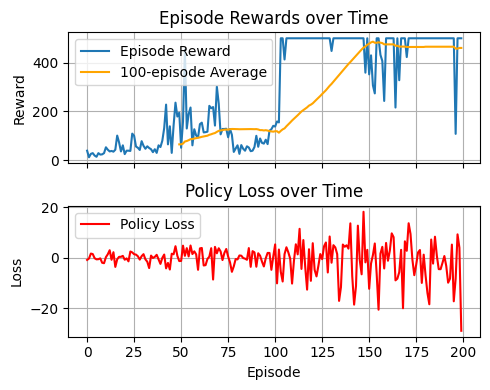

In [6]:
# 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4), sharex=True)

# 绘制 Rewards
ax1.plot(episode_rewards, label='Episode Reward')
running_avg = np.convolve(episode_rewards, np.ones(50)/50, mode='valid')
ax1.plot(np.arange(49, len(episode_rewards)), running_avg, label='100-episode Average', color='orange')
ax1.set_title('Episode Rewards over Time')
ax1.set_ylabel('Reward')
ax1.legend()
ax1.grid(True)

# 绘制 Loss
ax2.plot(episode_losses, label='Policy Loss', color='red')
ax2.set_title('Policy Loss over Time')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()